## Problem 2 - SOFM

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [2]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

5


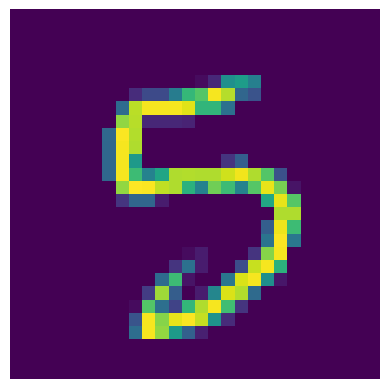

In [3]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [4]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [5]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [6]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### SOFM Implementation

In [19]:
class SOFM:
    def __init__(self, map_size=(12, 12), input_dim=784, alpha0=0.01, sigma0=5, epochs=100):
        self.rows, self.cols = map_size
        self.num_neurons = self.rows * self.cols
        self.input_dim = input_dim

        # Learning parameters
        self.alpha0 = alpha0
        self.sigma0 = sigma0
        self.epochs = epochs

        # Initialize random weights
        self.W = np.random.rand(self.num_neurons, self.input_dim)

        # Store neuron (row, col) positions
        self.positions = np.array([(i // self.cols, i % self.cols) for i in range(self.num_neurons)])

    
    ### Helper Functions ###

    # Returns the index of the best matching neuron for input X
    # Uses euclidian distance
    def find_bmu(self, x):
        distances = np.linalg.norm(self.W - x, axis=1)
        return np.argmin(distances)

    # Compute neighborhood influence on all neurons
    # This helps the map gain a smooth organized layout,
    # Where similar inputs activate neighboring neurons instead of
    # random spots
    def neighborhood_influence(self, bmu_idx, sigma):
        bmu_pos = self.positions[bmu_idx]
        dists = np.linalg.norm(self.positions - bmu_pos, axis=1)
        return np.exp(-(dists ** 2) / (2 * (sigma ** 2)))


    ### Training Function ###

    def train(self, train_data):
        for epoch in range(self.epochs):
            # Decay learning rate + neighborhood radius
            alpha = self.alpha0 * np.exp(-epoch / self.epochs)
            sigma = self.sigma0 * np.exp(-epoch / self.epochs)

            print(f"Epoch {epoch+1}/{self.epochs} — alpha={alpha:.4f}, sigma={sigma:.4f}")

            # Shuffle training set for better training
            np.random.shuffle(train_data)

            for x in train_data:
                bmu = self.find_bmu(x)
                h = self.neighborhood_influence(bmu, sigma)   # shape (num_neurons,)

                # Update all neurons
                self.W += (alpha * h[:, np.newaxis]) * (x - self.W)

    
    ### Testing / Activity Maps ###
    def test(self, test_data, test_labels):
        class_activity = np.zeros((10, self.num_neurons))  # 10 classes

        for x, label in zip(test_data, test_labels):
            bmu = self.find_bmu(x)
            class_activity[label, bmu] += 1

        # Convert counts → fractions (each digit has 100 samples)
        return class_activity / 100.0
    
    ##    Plot 10 heatmaps (12×12) for classes 0–9.
    ##    Input: class_activity of shape (10, num_neurons)
    def plot_activity_maps(self, class_activity):
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))

        for c in range(10):
            ax = axes[c // 5, c % 5]
            heatmap = class_activity[c].reshape(self.rows, self.cols)
            im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
            ax.set_title(f"Class {c}")
            ax.axis('off')

        plt.tight_layout()
        plt.show()


    ##    Plot the 12×12 grid of 28×28 neuron weight images.
    ##    Final image dimension = 336×336 (as required by assignment).
    def plot_weight_grid(self):
        fig, axes = plt.subplots(self.rows, self.cols, figsize=(10, 10))

        for i in range(self.num_neurons):
            r, c = i // self.cols, i % self.cols
            ax = axes[r, c]
            ax.imshow(self.W[i].reshape(28, 28), cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        


### Training and Testing Performance

In [20]:
som = SOFM(epochs=30)

som.train(X_train)

Epoch 1/30 — alpha=0.0100, sigma=5.0000
Epoch 2/30 — alpha=0.0097, sigma=4.8361
Epoch 3/30 — alpha=0.0094, sigma=4.6775
Epoch 4/30 — alpha=0.0090, sigma=4.5242
Epoch 5/30 — alpha=0.0088, sigma=4.3759
Epoch 6/30 — alpha=0.0085, sigma=4.2324
Epoch 7/30 — alpha=0.0082, sigma=4.0937
Epoch 8/30 — alpha=0.0079, sigma=3.9594
Epoch 9/30 — alpha=0.0077, sigma=3.8296
Epoch 10/30 — alpha=0.0074, sigma=3.7041
Epoch 11/30 — alpha=0.0072, sigma=3.5827
Epoch 12/30 — alpha=0.0069, sigma=3.4652
Epoch 13/30 — alpha=0.0067, sigma=3.3516
Epoch 14/30 — alpha=0.0065, sigma=3.2417
Epoch 15/30 — alpha=0.0063, sigma=3.1354
Epoch 16/30 — alpha=0.0061, sigma=3.0327
Epoch 17/30 — alpha=0.0059, sigma=2.9332
Epoch 18/30 — alpha=0.0057, sigma=2.8371
Epoch 19/30 — alpha=0.0055, sigma=2.7441
Epoch 20/30 — alpha=0.0053, sigma=2.6541
Epoch 21/30 — alpha=0.0051, sigma=2.5671
Epoch 22/30 — alpha=0.0050, sigma=2.4829
Epoch 23/30 — alpha=0.0048, sigma=2.4015
Epoch 24/30 — alpha=0.0046, sigma=2.3228
Epoch 25/30 — alpha=0.004

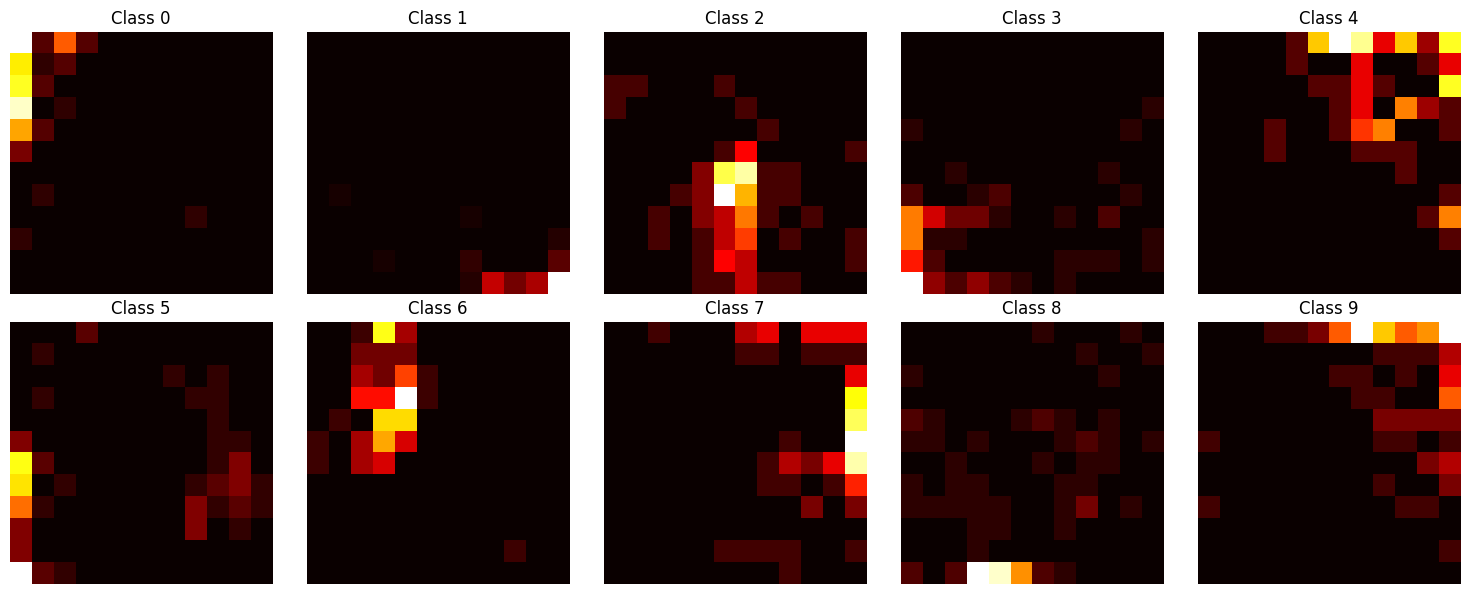

In [21]:
class_activity = som.test(X_test, Y_test)
som.plot_activity_maps(class_activity)


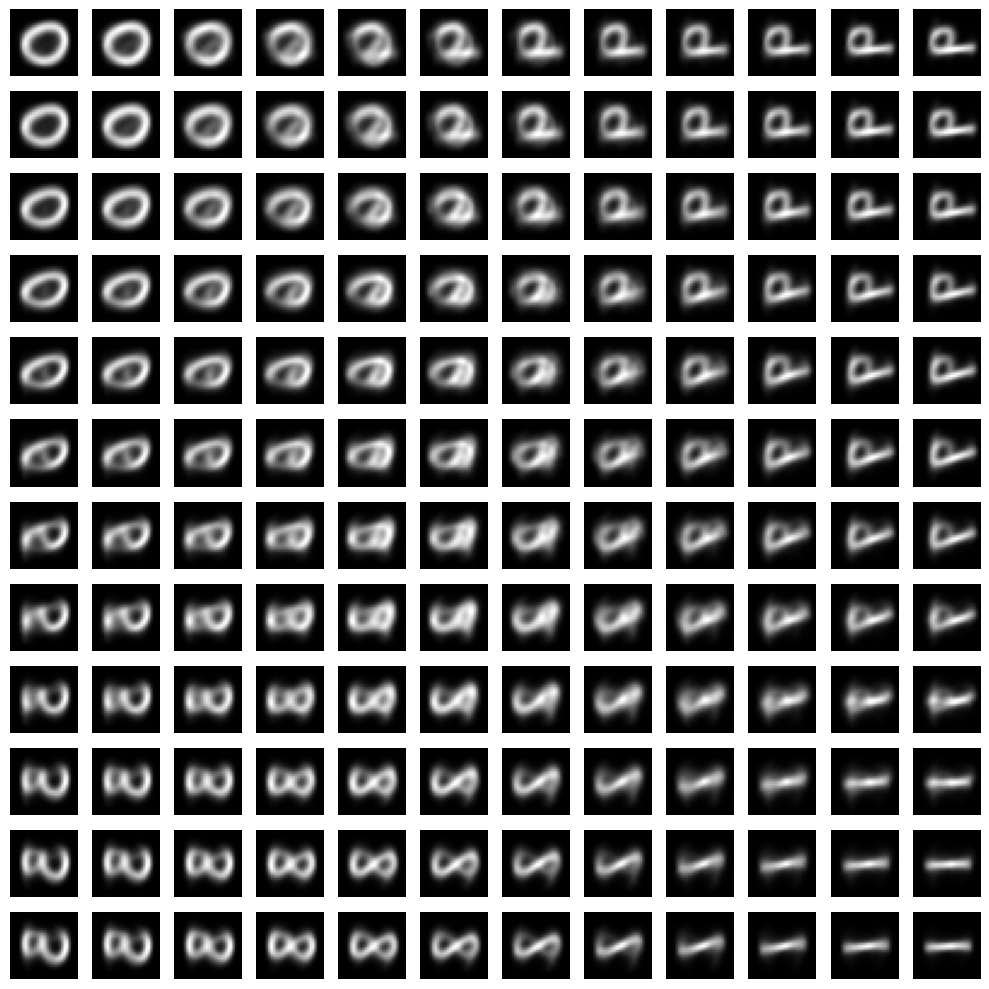

In [22]:
som.plot_weight_grid()